<a href="https://colab.research.google.com/github/jben-hun/pyground/blob/master/notebooks/hypothesisTesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hypothesis Testing

## 1. Introduction & contents

Here we'll explore simple hypothesis testing in python. In hypothesis testing, we have data samples, and we want to test various assumptions about their distributions. Our assumptions are called hypothese, and they will get accepted or rejected based on how much probability we allow for false assumptions. [1]

Tests performed:
*   One sample **Z-test** [2]: 3.1.
*   One sample **t-test** [5]: 3.2.
*   Two sample **Welch's t-test** [5]: 4.1.

## 2. Imports & common defintions

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="white")
np.random.seed(666)
ALPHA = .05


def show_test(x, y, crit_score, score):
    """Perform and display the results of a two-tailed  hypothesis test"""

    fig, ax = plt.subplots()

    ax.plot(x, y)

    # accept or refuse H0
    accept = -crit_score < score < crit_score
    color = "g" if accept else "r"

    ax.fill_between(x, 0, y, where=x > crit_score, color="red", alpha=.5)
    ax.fill_between(x, 0, y, where=x < -crit_score, color="red", alpha=.5,
                    label="significant regions")
    ax.axvline(score, color=color, label="test score")
    ax.set(title="H0 " + ("accepted" if accept else "rejected"))
    ax.legend()

## 3. One sample tests

*a.k.a. location tests*

Given a sample with size $n$, we want to know the likelihood of the sample coming from a specified population distribution.

*   The null hypothesis $H_0$ states that the sample comes from the said distribution,
*   and the alternate hypothesis $H_1$ states that it comes from another unknown distribution.

We decide by comparing calculated test score to critical test scores, which are derived from the $\alpha$ parameters. The $\alpha$ parameter specifies the accepted probability of falsefully rejecting $H_0$. In other words, $\alpha$ is a lower limit of the signifiance level.

*   **Confidence level:** typicall 95% or 99%
*   **Significance level:** ($\alpha$): 1 - confidence level, typicall 5% or 1%

The test scores also tell us the sign of the difference of the means, so the tests are asymmetric.

The tests in these examples are two tailed, as seen in the graphs below, the significant regions are symmetrical to the mean.

### 3.1. Z-test [2]

**Use when:**
*   The population is normally distributed with known variance, or the sample size is large enough ($\gtrapprox 50$), causing the sample means to start following a normal distribution due to the Central Limit Theorem [3]

Z-tests are based on Z-scores which follow the Z-distribution, which is the standard normal distribution. Z-scores are computed as follows:


$Z\text{-}score=\frac{\bar{x}-\mu}{SE}$

$SE=\frac{\sigma}{\sqrt{n}}$

$confidence\ interval=Z\text{-}score*SE$

*   SE (a.k.a. SEM) - standard error of the mean [4]
*   $\mu$ - population mean
*   $\bar{x}$ - sample mean
*   $\sigma$ - population standard deviation
*   $n$ - sample size

If the population variance is unknown, an approximated Z-test can be performed using the population variance approximated from the sample variance, but t-tests might better suit these cases.

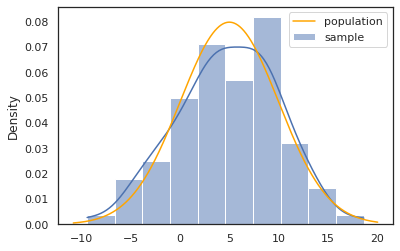

In [5]:
# generate data
pop_mean = 5
pop_std = 5
sample_size = 100
sample = np.random.normal(pop_mean, pop_std, sample_size)

# plot
fig, ax = plt.subplots()
sns.histplot(sample, kde=True, stat="density", ax=ax, label="sample")
x = np.linspace(*ax.get_xlim(), 1000)
y = stats.norm(pop_mean, pop_std).pdf(x)
sns.lineplot(x=x, y=y, color="orange", label="population", ax=ax);

Sample mean and confidence interval: 4.89 +- 0.98


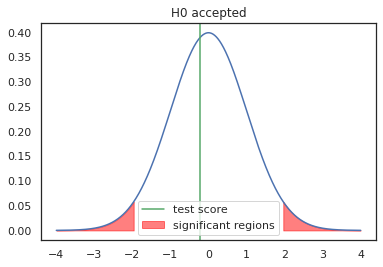

In [6]:
sem = pop_std / sample_size**.5 # standar error of the mean
score = (sample.mean() - pop_mean) / sem
score_dist = stats.norm # Z-tests are based on the normal distribution
crit_score = abs(score_dist.ppf(ALPHA / 2)) # critical score
ci = crit_score * sem # confidence interval
print(f"""Sample mean and confidence interval: """
      f"""{sample.mean():.2f} +- {ci:.2f}""")

# plot
x = np.linspace(min(-abs(score), -4), max(abs(score), 4), 1000)
y = score_dist.pdf(x)
show_test(x, y, crit_score, score)

### 3.2. T-test [5]

*a.k.a. Student's t-test*

**Use when:**
*   The sample size is small ($\lessapprox 50$) and the population variance is unknown

T-tests differ from Z-tests in that they are based on the t-distribution, which is a flattened standard normal distribution depending on the sample size. Smaller sample sizes mean less degrees of freedom, and the corresponding t-distribution parametrized with less degrees of freedom will be flattened to account for the uncertainty caused by the small amount of data. For large sample sizes, the t-distribution, and thus t-tests closely match a Z-test.

$t\text{-}score=\frac{\bar{x}-\mu}{\frac{\sigma_s}{\sqrt{n}}}$

$\sigma_s=\sqrt{\frac{\sum_i^n{\left(x_i-\bar{x}\right)^2}}{n-1}}$

$confidence\ interval=t{\text -}score*\frac{\sigma_s}{\sqrt{n}}$

*   SE (SEM) - standard error of the mean
*   $\mu$ - population mean
*   $\bar{x}$ - sample mean
*   $\sigma_s$ - corrected population standard deviation estimate [5]
*   $n$ - sample size

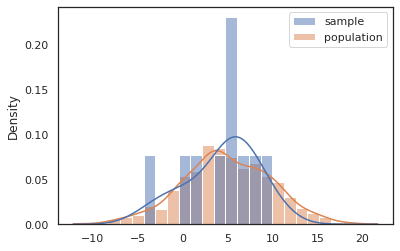

In [7]:
# generate data
pop_mean = 5
pop_std = 5
sample_size = 10
pop = np.random.normal(pop_mean, pop_std, 1000)
sample = np.random.choice(pop, sample_size)

# plot
sns.histplot({"sample":sample, "population":pop}, kde=True, stat="density",
             common_norm=False);

Sample mean and confidence interval: 4.35 +- 2.80


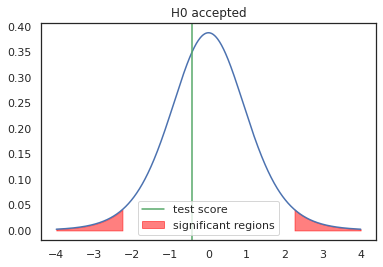

In [8]:
score = stats.ttest_1samp(sample, pop.mean())[0]
score_dist = stats.t(df=sample_size - 1)
crit_score = abs(score_dist.ppf(ALPHA / 2)) # critical score
# confidence interval
ci = crit_score * sample.std(ddof=1) / sample_size**.5
print(f"""Sample mean and confidence interval: """
      f"""{sample.mean():.2f} +- {ci:.2f}""")

# plot
x = np.linspace(min(-abs(score), -4), max(abs(score), 4), 1000)
y = score_dist.pdf(x)
show_test(x, y, crit_score, score)

## 4. Two sample tests

### 4.1. Welch's t-test [5]

The population variances will be unknown (estimated), so the appropriate test here is Welch's t-test, which is a version of two sample t-test for just this purpose.

$t\text{-}score=\frac{\bar{x}_1-\bar{x}_2}{\sqrt{\frac{v_1}{n_1}+\frac{v_2}{n_2}}}$

$v_i=\frac{\sum_j^{n_i}{\left(x_{ij}-\bar{x_i}\right)^2}}{n_i-1}$

$d\text{.}o\text{.}f\text{.}=\frac{\left(\frac{v_1}{n_1}+\frac{v_2}{n_2}\right)^2}{\frac{\left(v_1/n_1^2\right)^2}{n_1-1}+\frac{\left(v_2/n_2^2\right)^2}{n_2-2}}$

*   $x_{ij}$ - element $j$ of sample $i$
*   $\bar{x}_i$ - sample mean of sample $i$
*   $n_i$ - size of sample $i$
*   $v_i$ - corrected (thus unbiased) variance of sample $i$ [6]
*   $d\text{.}o\text{.}f\text{.}$ - degrees of freedom

Let's perform this on some "real world" data, where we compare flipper lengths of penguin species. 🐧

In [9]:
penguins = sns.load_dataset("penguins")
print(f"columns: {penguins.columns.values}")
print(f"""\ndata counts: {penguins.groupby("species").size()}""")

columns: ['species' 'island' 'bill_length_mm' 'bill_depth_mm' 'flipper_length_mm'
 'body_mass_g' 'sex']

data counts: species
Adelie       152
Chinstrap     68
Gentoo       124
dtype: int64


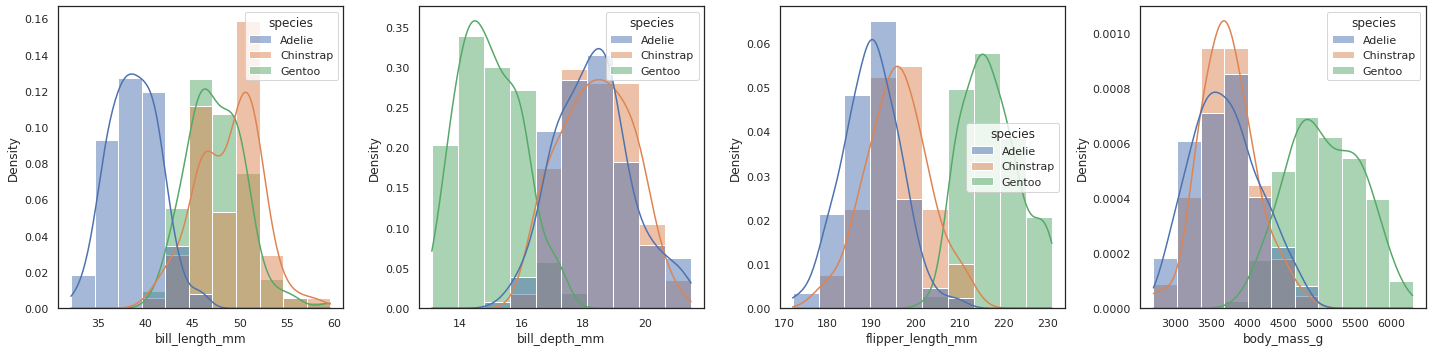

In [10]:
fig, axs = plt.subplots(1, 4, figsize=[20, 5])
for i, col in enumerate(["bill_length_mm", "bill_depth_mm",
                         "flipper_length_mm", "body_mass_g"]):
    sns.histplot(penguins, x=col, hue="species", common_norm=False,
                 stat="density", kde=True, ax=axs[i]);
fig.tight_layout()

Let's choose **flipper_length_mm** to be our feature, since all the species seem to have differing means, and the distributions seem to resemble bell curves.

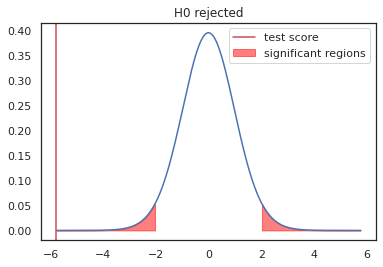

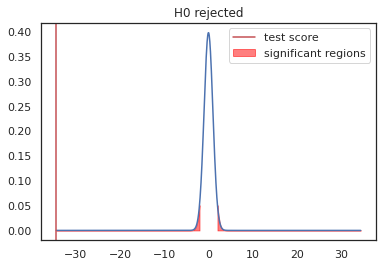

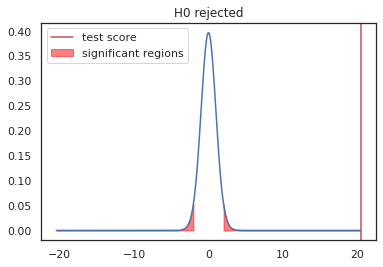

In [11]:
def get_scpecies(species, feature):
    return penguins.loc[penguins["species"] == species, feature].dropna()

def welch_dof(a, b):
    var_a = a.var(ddof=1)
    var_b = b.var(ddof=1)
    n_a = len(a)
    n_b = len(b)
    numerator = (var_a/n_a + var_a / n_a)**2
    denominator = (var_a / n_a)**2 / (n_a-1) + (var_b / n_b)**2 / (n_b - 1)
    return numerator / denominator

def welch_test(a, b):
    score = stats.ttest_ind(a, b, equal_var=False)[0]
    dof = welch_dof(a, b)
    score_dist = stats.t(df=dof)
    crit_score = abs(score_dist.ppf(ALPHA / 2)) # critical score

    # plot
    x = np.linspace(min(-abs(score), -4), max(abs(score), 4), 1000)
    y = score_dist.pdf(x)
    show_test(x, y, crit_score, score)


feature = "flipper_length_mm"

adelie = get_scpecies("Adelie", feature)
chinstrap = get_scpecies("Chinstrap", feature)
gentoo = get_scpecies("Gentoo", feature)

welch_test(adelie, chinstrap)
welch_test(adelie, gentoo)
welch_test(gentoo, chinstrap)

With 95% confidence, no two species of penguins from this dataset has the same mean flipper length.

# References

1.   <https://en.wikipedia.org/wiki/Statistical_hypothesis_testing>
2.   <https://en.wikipedia.org/wiki/Z-test>
3.   <https://en.wikipedia.org/wiki/Central_limit_theorem>
4.   <https://en.wikipedia.org/wiki/Standard_error>
5.   <https://en.wikipedia.org/wiki/Student%27s_t-test>
6.   <https://en.wikipedia.org/wiki/Bessel%27s_correction>